In [22]:
import sys, warnings
import numpy as np
import pandas as pd
import torch
import matplotlib.pyplot as plt
from tqdm.auto import tqdm
from pathlib import Path
from chronos import ChronosPipeline

sys.path.insert(0, str(Path('..') / 'timesfm_google'))
sys.path.insert(0, '.')   # makes tsfm_public importable from notebook dir

from benchmark.forecasters.naive       import NaiveBenchmarkForecaster
from benchmark.forecasters.arima       import ARIMAForecaster
from benchmark.forecasters.auto_arima  import AutoARIMAForecaster
from benchmark.forecasters.bayesian_ar import BayesianARForecaster
from benchmark.forecasters.ml_bayes_ar import MLBayesARForecaster
from benchmark.forecasters.ssa         import SSAForecaster
from benchmark.forecasters.ar_garch    import ARGARCHForecaster

from tsfm_public.toolkit.util import convert_tsf_to_dataframe

warnings.filterwarnings('ignore')
plt.style.use('seaborn-v0_8-whitegrid')
print("Imports OK")

Imports OK


In [23]:
HORIZON         = 1
CHRONOS_CONTEXT = 512
CHRONOS_MODEL   = 'amazon/chronos-t5-tiny'   # swap small/base for higher quality
MAX_OOS_ORIGINS = 100
ROLLING_WINDOW  = 36

TSF_DIR     = Path('data/similar domain')
RESULTS_DIR = Path('results/similar_domain')

# Set RUN_DATASETS = None to run all 11 series.
RUN_DATASETS = None

# Full colour registry
COLORS = {
    'Chronos'  : 'steelblue',
    'Naive'    : 'gray',
    'AR(1)'    : 'green',
    'AutoARIMA': 'darkorange',
    'BayesAR'  : 'purple',
    'MLBayesAR': 'crimson',
    'SSA'      : 'saddlebrown',
    'AR-GARCH' : 'teal',
}

In [24]:
DATASETS = []

# ── Saugeen river (daily, 1 series, first 500 obs) ───────────────────────────
df_s, *_ = convert_tsf_to_dataframe(TSF_DIR / 'saugeenday_dataset.tsf')
row = df_s.iloc[0]
vals  = np.array(row['series_value'], dtype=float)[:500]
start = pd.to_datetime(str(row['start_timestamp']).split()[0])
dates = pd.date_range(start, periods=len(vals), freq='D').values
DATASETS.append(dict(name='Saugeen', values=vals, dates=dates, k_first=100))

# ── Australian electricity (half-hourly → daily mean, 5 series) ──────────────
df_e, *_ = convert_tsf_to_dataframe(TSF_DIR / 'australian_electricity_demand_dataset.tsf')
state_names = ['NSW', 'VIC', 'QLD', 'SA', 'TAS']
for i, (_, row) in enumerate(df_e.iterrows()):
    label = state_names[i] if i < len(state_names) else row['series_name']
    start = pd.to_datetime(str(row['start_timestamp']).split()[0])
    raw   = np.array(row['series_value'], dtype=float)
    ts    = pd.Series(raw, index=pd.date_range(start, periods=len(raw), freq='30min'))
    daily = ts.resample('D').mean()
    vals  = daily.values[:500]
    DATASETS.append(dict(name=f'Elec_{label}', values=vals,
                         dates=daily.index.values[:500], k_first=100))

# ── Hospital patient counts (monthly, first 5 series, 84 obs each) ───────────
df_h, *_ = convert_tsf_to_dataframe(TSF_DIR / 'hospital_dataset.tsf')
for i, (_, row) in enumerate(df_h.head(5).iterrows()):
    start = pd.to_datetime(str(row['start_timestamp']).split()[0])
    vals  = np.array(row['series_value'], dtype=float)[:500]
    dates = pd.date_range(start, periods=len(vals), freq='MS').values
    DATASETS.append(dict(name=f'Hospital_T{i+1}', values=vals, dates=dates, k_first=36))

print(f'{len(DATASETS)} datasets loaded:')
for ds in DATASETS:
    print(f"  {ds['name']:20s}  n={len(ds['values'])}  k_first={ds['k_first']}")

11 datasets loaded:
  Saugeen               n=500  k_first=100
  Elec_NSW              n=500  k_first=100
  Elec_VIC              n=500  k_first=100
  Elec_QLD              n=500  k_first=100
  Elec_SA               n=500  k_first=100
  Elec_TAS              n=500  k_first=100
  Hospital_T1           n=84  k_first=36
  Hospital_T2           n=84  k_first=36
  Hospital_T3           n=84  k_first=36
  Hospital_T4           n=84  k_first=36
  Hospital_T5           n=84  k_first=36


In [25]:
# ┌─────────────────────────────────────────────────────────────────┐
# │  MODEL SELECTION — comment out any line to drop that model      │
# └─────────────────────────────────────────────────────────────────┘

RUN_CHRONOS = True   # set False to skip the Chronos-T5 pipeline entirely

def make_baselines():
    return {
        'Naive'    : NaiveBenchmarkForecaster(),
        # 'AR(1)'    : ARIMAForecaster(order=(1, 0, 0)),
        'AutoARIMA': AutoARIMAForecaster(p_max=3, q_max=2, d_max=1),
        'BayesAR'  : BayesianARForecaster(p=10, prior_mode='ridge'),
        # 'MLBayesAR': MLBayesARForecaster(p=24, prior_mode='minnesota'),
        'SSA'      : SSAForecaster(),
        # 'AR-GARCH' : ARGARCHForecaster(p=1),
    }

# MODEL_NAMES is derived automatically — do not edit manually
_probe      = make_baselines()
MODEL_NAMES = (['Chronos'] if RUN_CHRONOS else []) + list(_probe.keys())
del _probe
print(f"Active models: {MODEL_NAMES}")

Active models: ['Chronos', 'Naive', 'AutoARIMA', 'BayesAR', 'SSA']


In [26]:
(RESULTS_DIR / 'plots').mkdir(parents=True, exist_ok=True)
print(f"Results dir: {RESULTS_DIR.resolve()}")

Results dir: /Users/nikhileshbelulkar/Documents/TSF_models/granite-tsfm/results/similar_domain


In [27]:
if RUN_CHRONOS:
    device = 'cuda' if torch.cuda.is_available() else 'cpu'
    dtype  = torch.bfloat16 if device == 'cuda' else torch.float32
    pipeline = ChronosPipeline.from_pretrained(
        CHRONOS_MODEL, device_map=device, torch_dtype=dtype,
    )
    print(f"Loaded {CHRONOS_MODEL} on {device}")
else:
    pipeline = None
    print("Chronos skipped (RUN_CHRONOS = False)")

Loaded amazon/chronos-t5-tiny on cpu


In [28]:
def chronos_predict_one_step(pipeline, history_values):
    ctx = history_values[-CHRONOS_CONTEXT:] if len(history_values) > CHRONOS_CONTEXT else history_values
    context = torch.tensor(np.array(ctx, dtype=np.float32))
    forecast = pipeline.predict(context, prediction_length=1)
    samples = forecast[0, :, 0].detach().cpu().numpy()
    return (
        float(np.quantile(samples, 0.50)),
        float(np.quantile(samples, 0.10)),
        float(np.quantile(samples, 0.90)),
    )


def compute_metrics(preds, actuals, lowers=None, uppers=None):
    p, a = np.array(preds, dtype=float), np.array(actuals, dtype=float)
    mask = ~np.isnan(p)
    e = p[mask] - a[mask]
    result = dict(
        n_forecasts=int(mask.sum()),
        mse=float(np.mean(e**2)),
        rmse=float(np.sqrt(np.mean(e**2))),
        mae=float(np.mean(np.abs(e))),
        coverage_80=float('nan'),
        avg_interval_width=float('nan'),
    )
    if lowers is not None and uppers is not None:
        lo = np.array(lowers, dtype=float)
        hi = np.array(uppers, dtype=float)
        im = mask & ~np.isnan(lo) & ~np.isnan(hi)
        if im.sum() > 0:
            result['coverage_80']        = float(np.mean((lo[im] <= a[im]) & (a[im] <= hi[im])))
            result['avg_interval_width'] = float(np.mean(hi[im] - lo[im]))
    return result


def rolling_mean(x, w):
    return pd.Series(np.array(x, dtype=float)).rolling(w, min_periods=1).mean().values

In [29]:
import time

all_metrics_rows  = []
all_forecast_rows = []
all_failure_rows  = []
dataset_results   = {}

active_datasets = [ds for ds in DATASETS
                   if RUN_DATASETS is None or ds['name'] in RUN_DATASETS]

for ds in active_datasets:
    t_ds_start = time.time()
    print(f"\n{'='*60}")
    print(f"Dataset: {ds['name']}")

    # Data comes from pre-built arrays in DATASETS — no CSV loading needed
    values = ds['values']
    dates  = ds['dates']
    n      = len(values)
    print(f"  Series length: {n}")

    origins = list(range(ds['k_first'], n))
    if len(origins) > MAX_OOS_ORIGINS:
        origins = origins[-MAX_OOS_ORIGINS:]
    print(f"  OOS origins: {len(origins)}  (t={origins[0]} .. {origins[-1]})")

    baselines = make_baselines()

    preds_ds  = {m: [] for m in MODEL_NAMES}
    lowers_ds = {m: [] for m in MODEL_NAMES}
    uppers_ds = {m: [] for m in MODEL_NAMES}
    actuals_ds = []
    dates_oos  = []

    for t in tqdm(origins, desc=ds['name']):
        history = values[:t]
        y_true  = values[t]
        actuals_ds.append(y_true)
        dates_oos.append(dates[t])

        if RUN_CHRONOS:
            try:
                p_c, lo_c, hi_c = chronos_predict_one_step(pipeline, history)
            except Exception as ex:
                all_failure_rows.append(dict(dataset=ds['name'], model='Chronos', error_message=str(ex)))
                p_c, lo_c, hi_c = float('nan'), float('nan'), float('nan')
            preds_ds['Chronos'].append(p_c)
            lowers_ds['Chronos'].append(lo_c)
            uppers_ds['Chronos'].append(hi_c)

        for name, fc in baselines.items():
            if name not in MODEL_NAMES:
                continue
            try:
                fc.fit(history)
                p_fc = float(fc.predict(1)[0])
                result = fc.predict_quantiles(1)
                if result is None:
                    lo_fc, hi_fc = float('nan'), float('nan')
                else:
                    levels = np.asarray(result[0])
                    qvals  = np.asarray(result[1])
                    lo_idx = int(np.argmin(np.abs(levels - 0.10)))
                    hi_idx = int(np.argmin(np.abs(levels - 0.90)))
                    lo_fc  = float(qvals[lo_idx, 0])
                    hi_fc  = float(qvals[hi_idx, 0])
            except Exception as ex:
                all_failure_rows.append(dict(dataset=ds['name'], model=name, error_message=str(ex)))
                p_fc, lo_fc, hi_fc = float('nan'), float('nan'), float('nan')
            preds_ds[name].append(p_fc)
            lowers_ds[name].append(lo_fc)
            uppers_ds[name].append(hi_fc)

        for model in MODEL_NAMES:
            all_forecast_rows.append(dict(
                dataset=ds['name'], date=dates[t], model=model,
                y_true=y_true,
                y_pred=preds_ds[model][-1],
                lower_80=lowers_ds[model][-1],
                upper_80=uppers_ds[model][-1],
            ))

    naive_m     = compute_metrics(preds_ds['Naive'], actuals_ds, lowers_ds['Naive'], uppers_ds['Naive'])
    naive_rmse  = naive_m['rmse']
    naive_mae   = naive_m['mae']
    naive_width = naive_m['avg_interval_width']
    for model in MODEL_NAMES:
        m = compute_metrics(preds_ds[model], actuals_ds, lowers_ds[model], uppers_ds[model])
        m['rmse_over_naive']           = m['rmse'] / naive_rmse  if naive_rmse  > 0 else float('nan')
        m['mae_over_naive']            = m['mae']  / naive_mae   if naive_mae   > 0 else float('nan')
        naive_w = naive_width if (not np.isnan(naive_width) and naive_width > 0) else float('nan')
        m['interval_width_over_naive'] = m['avg_interval_width'] / naive_w if not np.isnan(naive_w) else float('nan')
        m['dataset'] = ds['name']
        m['model']   = model
        all_metrics_rows.append(m)

    dataset_results[ds['name']] = dict(
        actuals=np.array(actuals_ds),
        preds=preds_ds, lowers=lowers_ds, uppers=uppers_ds, dates=dates_oos,
    )

    elapsed = time.time() - t_ds_start
    print(f"  Done: {len(origins)} origins in {elapsed:.1f}s  ({elapsed/len(origins):.2f}s/origin)")

print("\nAll datasets complete.")


Dataset: Saugeen
  Series length: 500
  OOS origins: 100  (t=400 .. 499)


Saugeen:   0%|          | 0/100 [00:00<?, ?it/s]

  Done: 100 origins in 86.4s  (0.86s/origin)

Dataset: Elec_NSW
  Series length: 500
  OOS origins: 100  (t=400 .. 499)


Elec_NSW:   0%|          | 0/100 [00:00<?, ?it/s]

  Done: 100 origins in 106.6s  (1.07s/origin)

Dataset: Elec_VIC
  Series length: 500
  OOS origins: 100  (t=400 .. 499)


...

  Done: 48 origins in 12.1s  (0.25s/origin)

Dataset: Hospital_T4
  Series length: 84
  OOS origins: 48  (t=36 .. 83)


Hospital_T4:   0%|          | 0/48 [00:00<?, ?it/s]

  Done: 48 origins in 12.1s  (0.25s/origin)

Dataset: Hospital_T5
  Series length: 84
  OOS origins: 48  (t=36 .. 83)


Hospital_T5:   0%|          | 0/48 [00:00<?, ?it/s]

  Done: 48 origins in 12.2s  (0.25s/origin)

All datasets complete.


In [30]:
METRICS_COLS = ['dataset', 'model', 'rmse', 'mae', 'rmse_over_naive', 'mae_over_naive',
                'coverage_80', 'avg_interval_width', 'interval_width_over_naive']

metrics_df = pd.DataFrame(all_metrics_rows)[METRICS_COLS]
metrics_df.to_csv(RESULTS_DIR / 'metrics_summary.csv', index=False)
print(f"Saved metrics_summary.csv  ({len(metrics_df)} rows)")

pd.DataFrame(all_forecast_rows).to_parquet(RESULTS_DIR / 'forecast_records.parquet', index=False)
print(f"Saved forecast_records.parquet")

failures_df = (pd.DataFrame(all_failure_rows) if all_failure_rows
               else pd.DataFrame(columns=['dataset', 'model', 'error_message']))
failures_df.to_csv(RESULTS_DIR / 'model_failures.csv', index=False)
print(f"Saved model_failures.csv  ({len(failures_df)} failures)")

print("\nMetrics summary:")
display(metrics_df)

Saved metrics_summary.csv  (55 rows)
Saved forecast_records.parquet
Saved model_failures.csv  (0 failures)

Metrics summary:


,dataset,model,rmse,mae,rmse_over_naive,mae_over_naive,coverage_80,avg_interval_width,interval_width_over_naive
0,Saugeen,Chronos,15.089692,8.814357,0.995655,0.986719,0.460000,6.175400,0.302927
1,Saugeen,Naive,15.155550,8.933000,1.000000,1.000000,0.730000,20.385772,1.000000
2,Saugeen,AutoARIMA,13.499907,7.411153,0.890757,0.829638,0.790000,18.998863,0.931967
3,Saugeen,BayesAR,13.443650,7.793307,0.887045,0.872418,0.780000,19.493124,0.956212
4,Saugeen,SSA,16.687001,12.707002,1.101049,1.422479,0.510000,25.178706,1.235112
5,Elec_NSW,Chronos,287.171299,194.369762,0.487790,0.460857,0.800000,581.073359,0.351673
6,Elec_NSW,Naive,588.719644,421.757615,1.000000,1.000000,0.780000,1652.309901,1.000000
7,Elec_NSW,AutoARIMA,377.060970,308.996676,0.640476,0.732640,0.850000,1109.362247,0.671401
8,Elec_NSW,BayesAR,250.904332,187.014133,0.426186,0.443416,0.910000,874.295641,0.529135
9,Elec_NSW,SSA,242.132761,173.156324,0.411287,0.410559,0.990000,1542.956216,0.933818


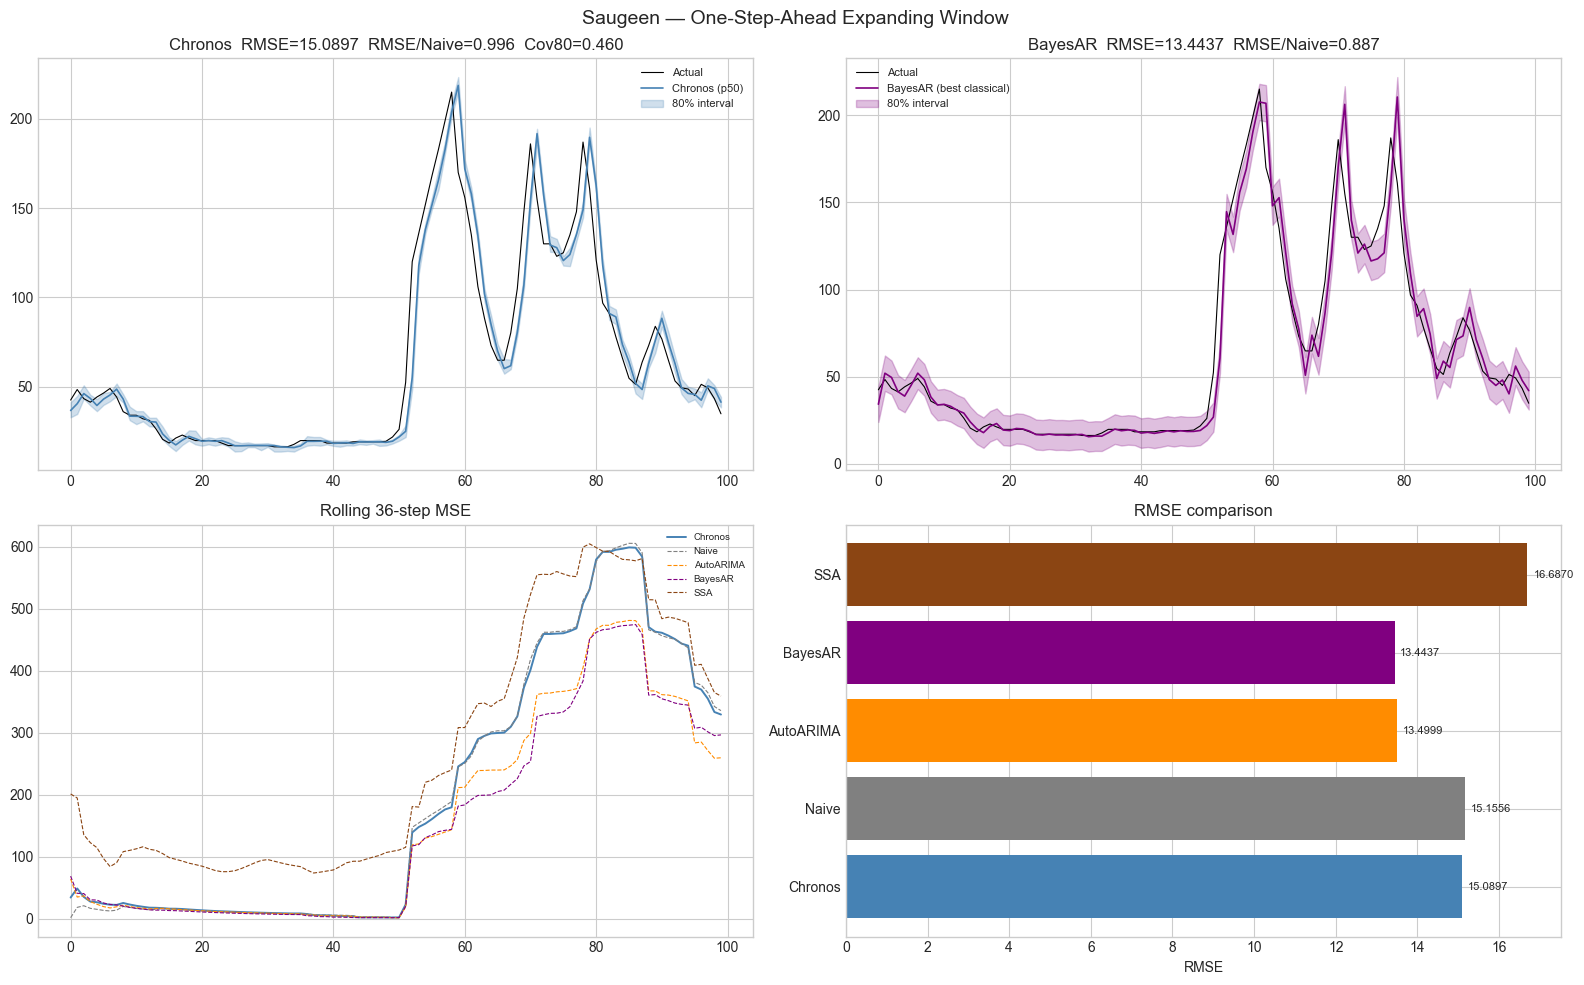

Saved results/similar_domain/plots/Saugeen_benchmark.png


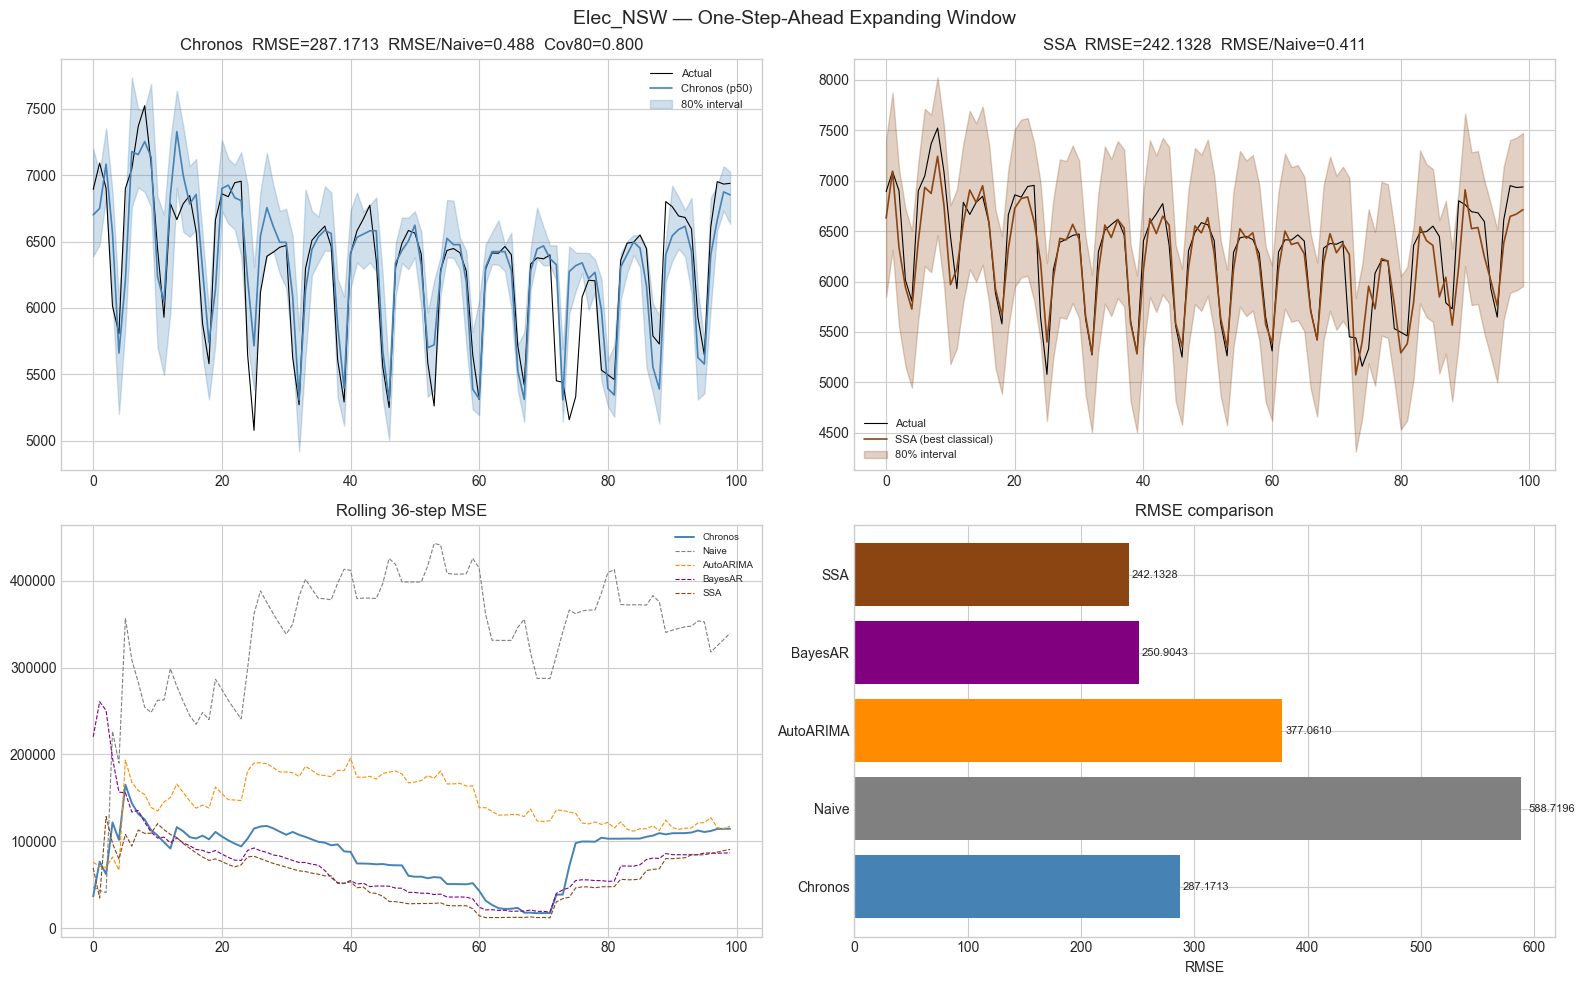

Saved results/similar_domain/plots/Elec_NSW_benchmark.png


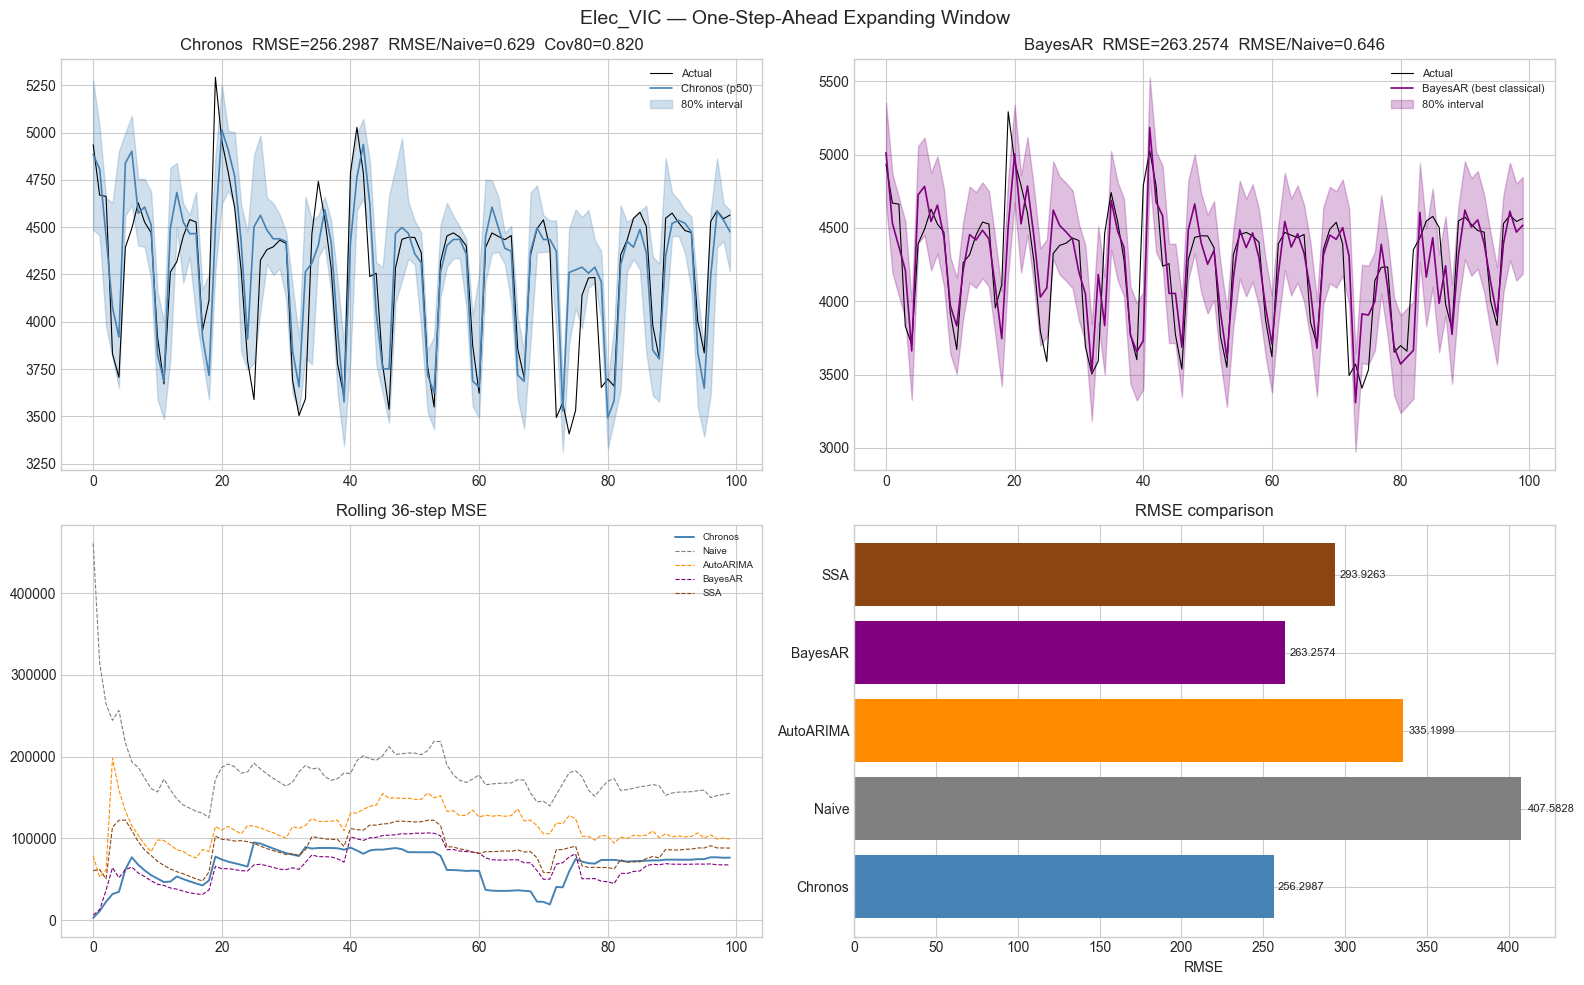

Saved results/similar_domain/plots/Elec_VIC_benchmark.png


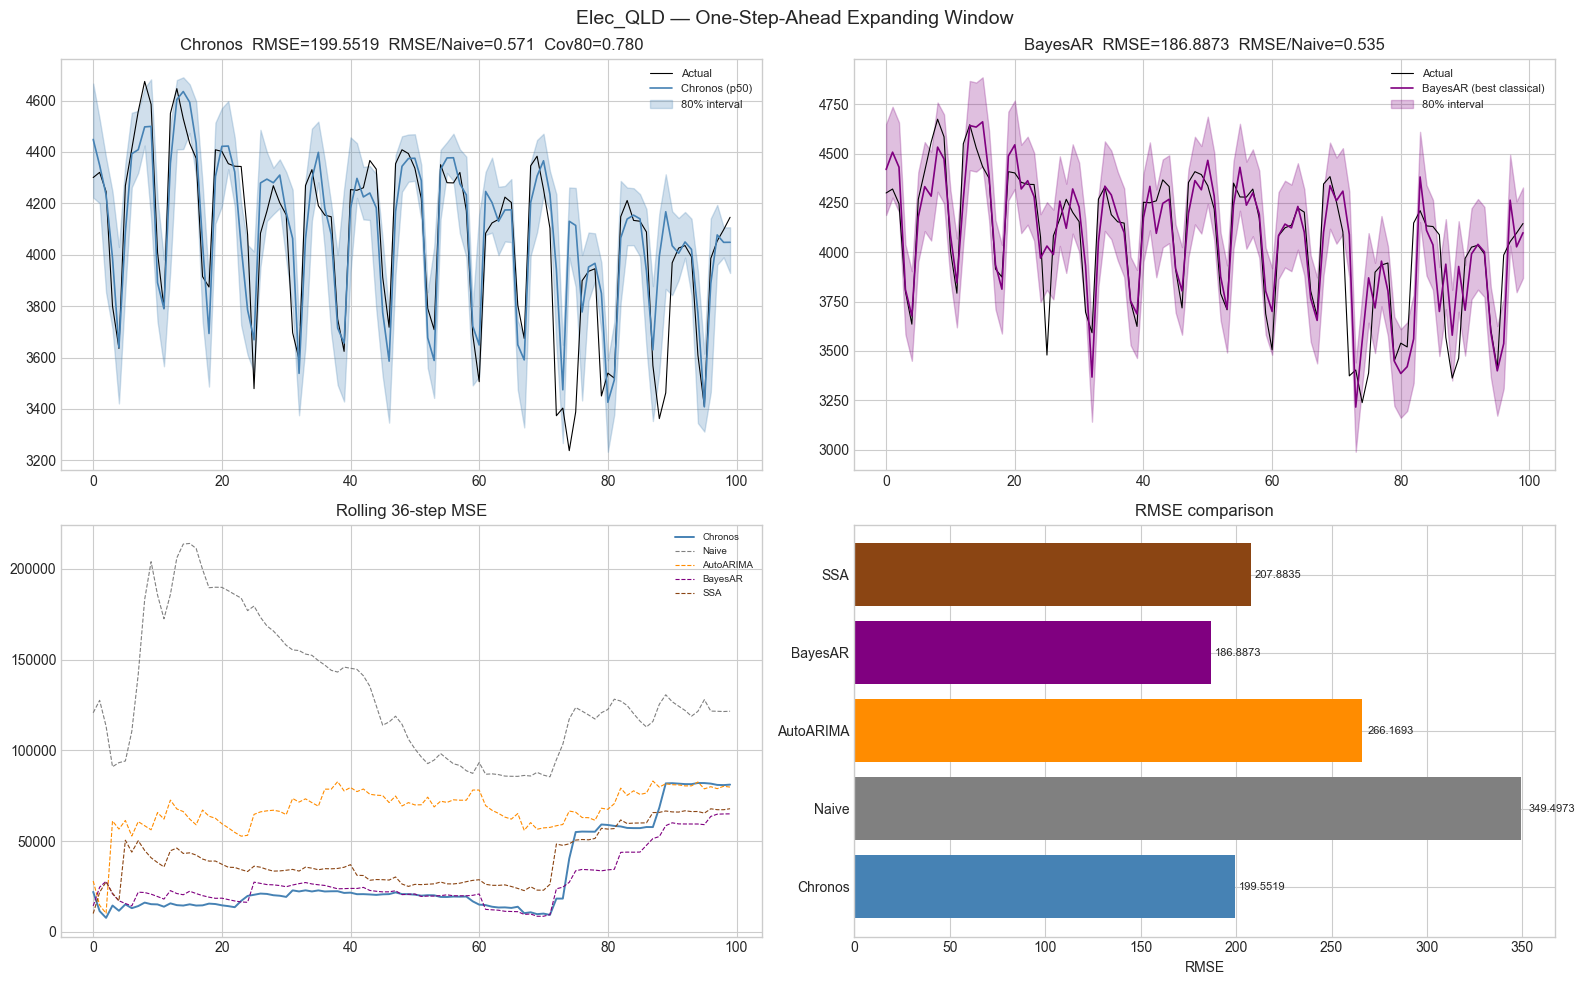

Saved results/similar_domain/plots/Elec_QLD_benchmark.png


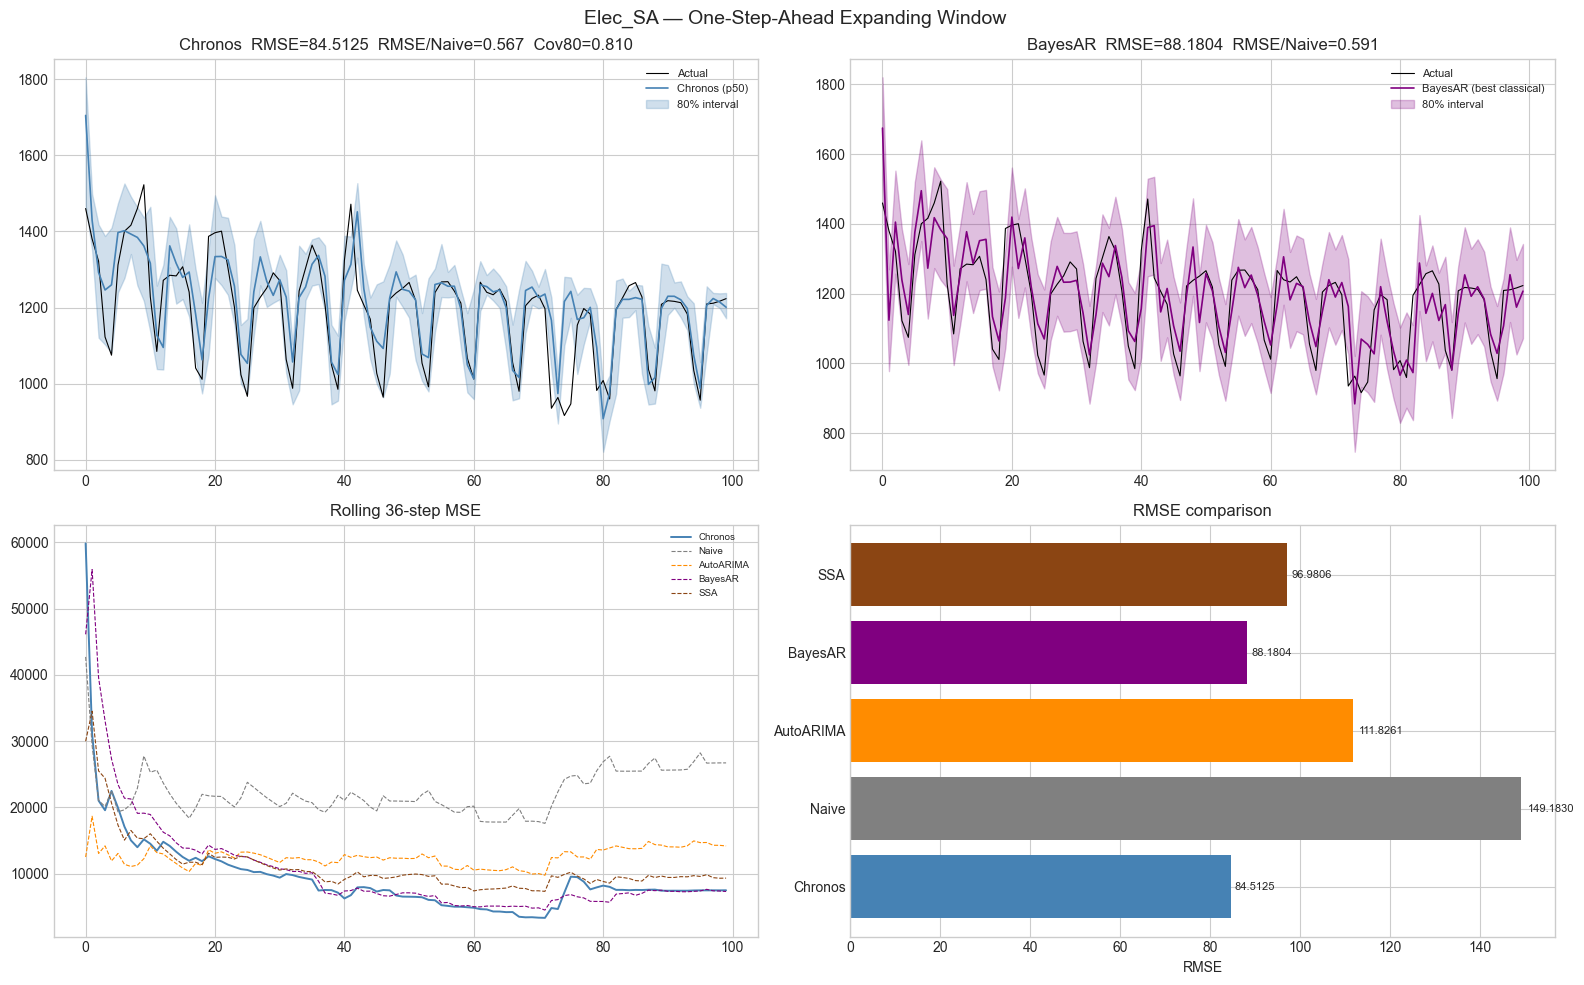

Saved results/similar_domain/plots/Elec_SA_benchmark.png


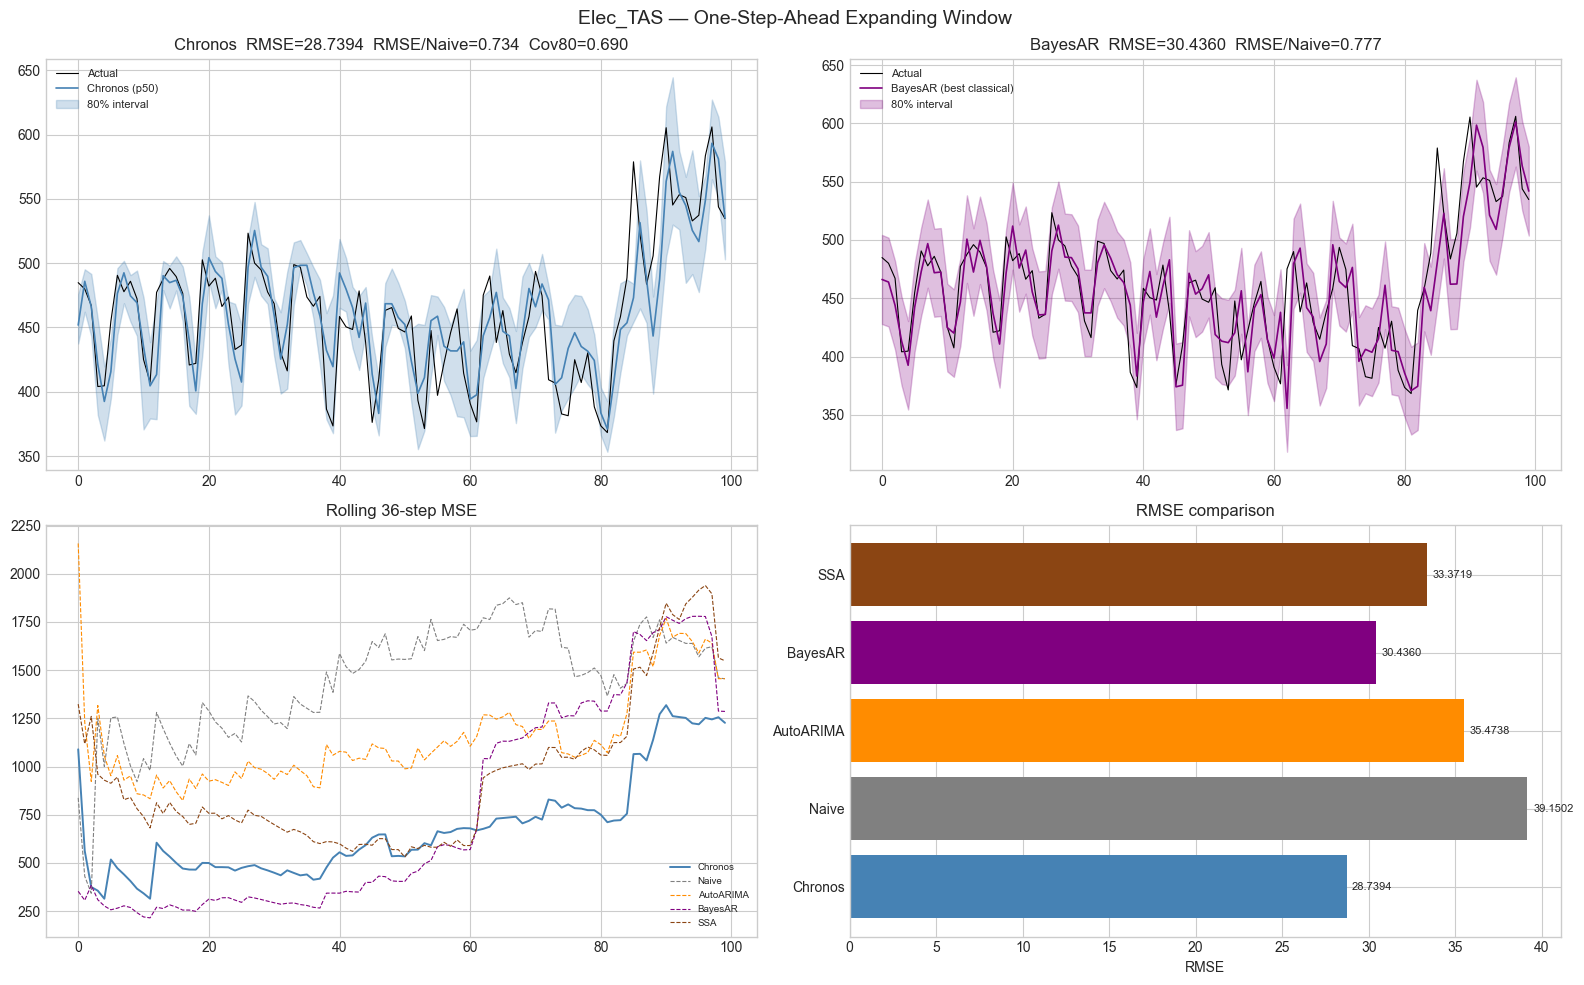

Saved results/similar_domain/plots/Elec_TAS_benchmark.png


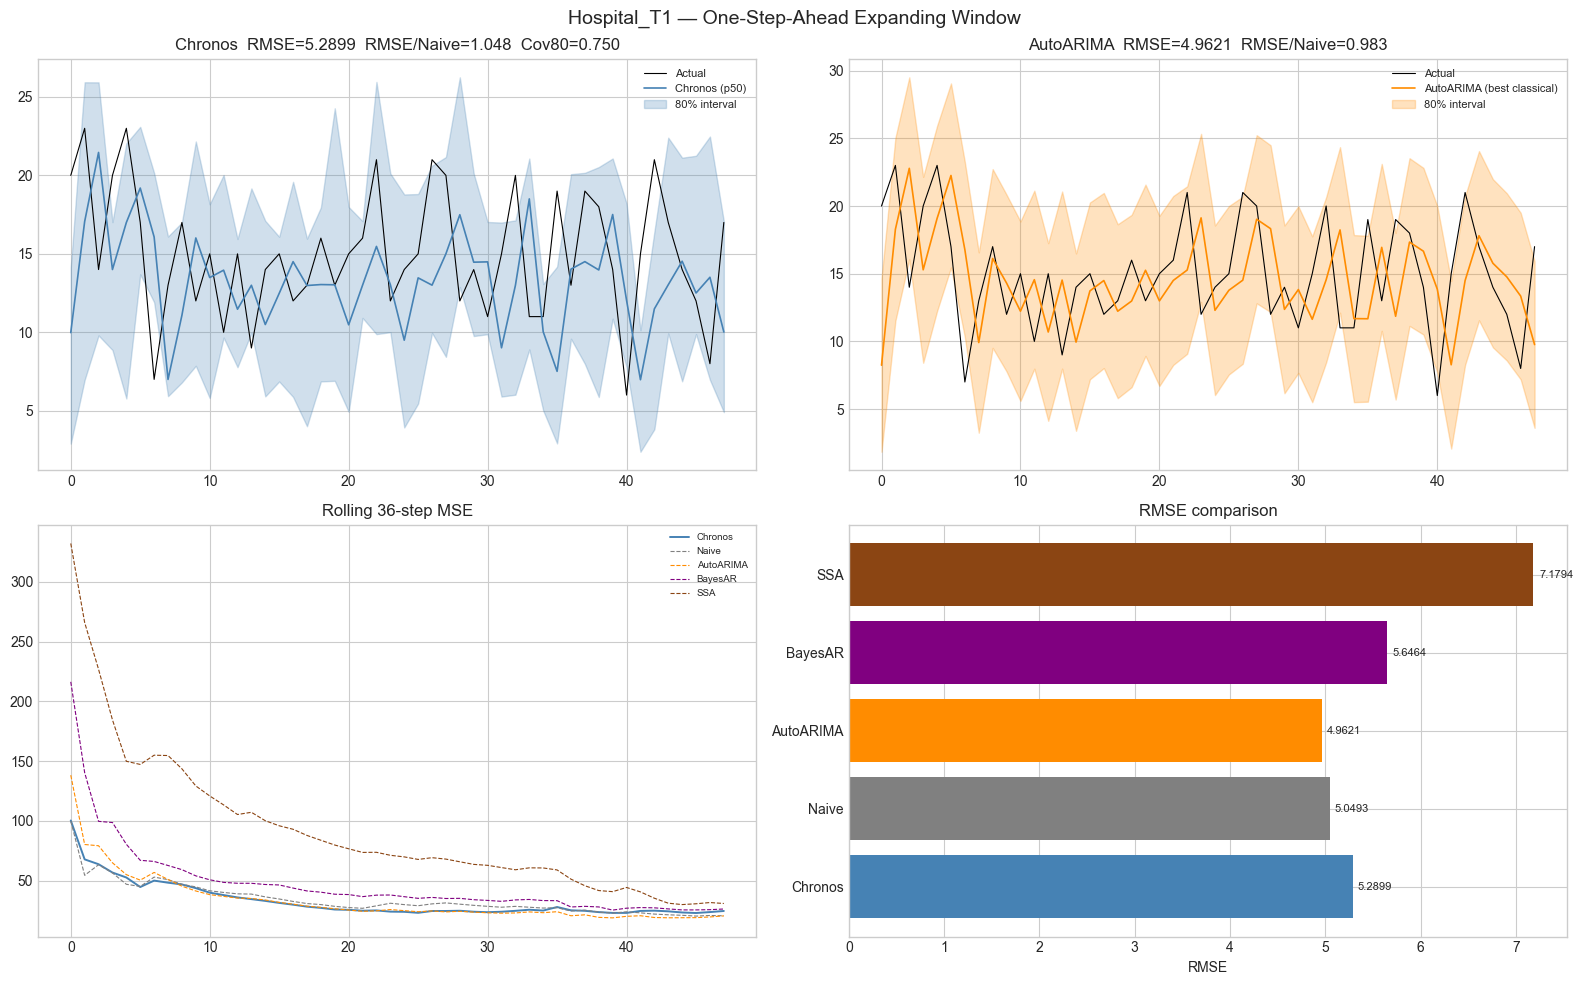

Saved results/similar_domain/plots/Hospital_T1_benchmark.png


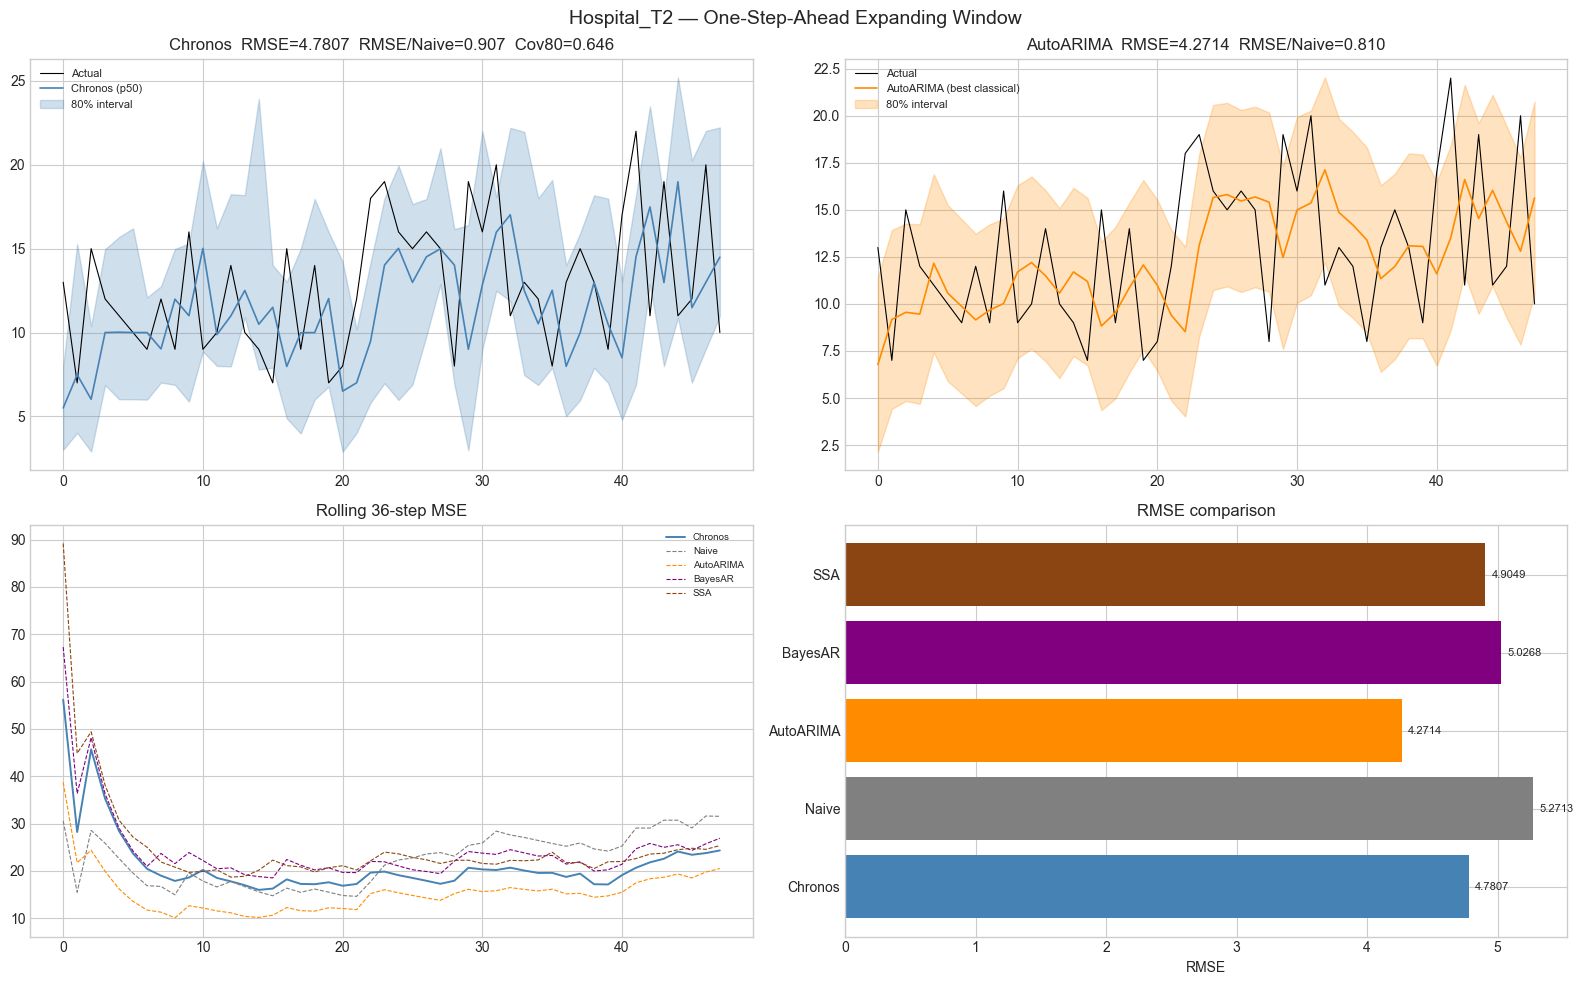

Saved results/similar_domain/plots/Hospital_T2_benchmark.png


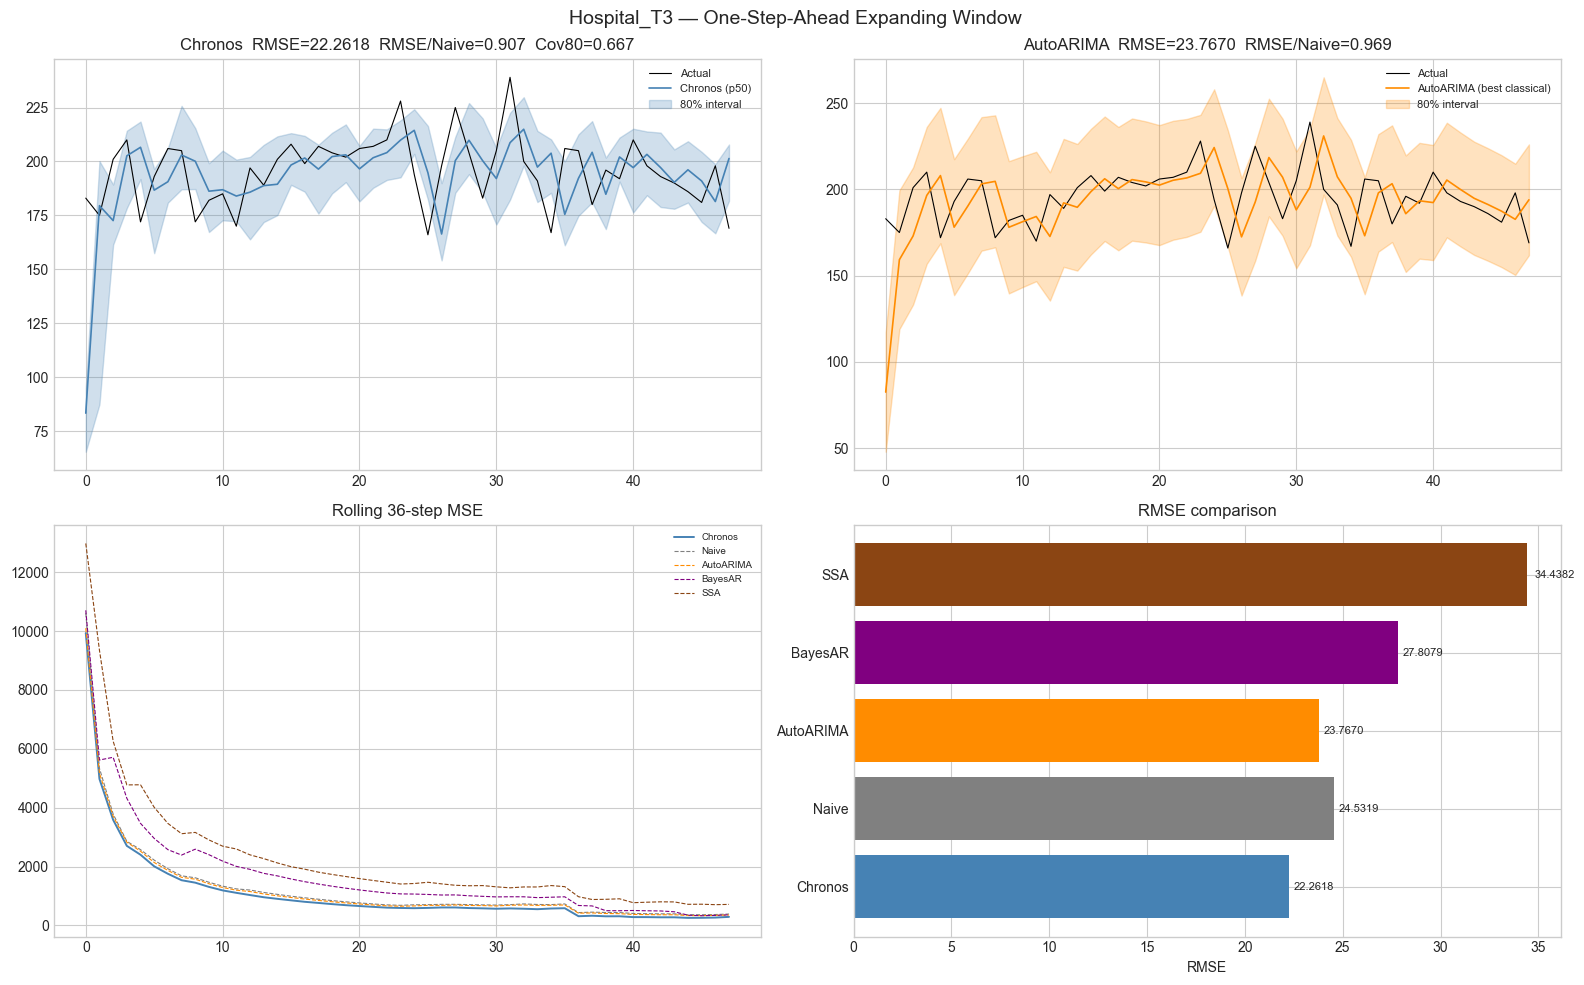

Saved results/similar_domain/plots/Hospital_T3_benchmark.png


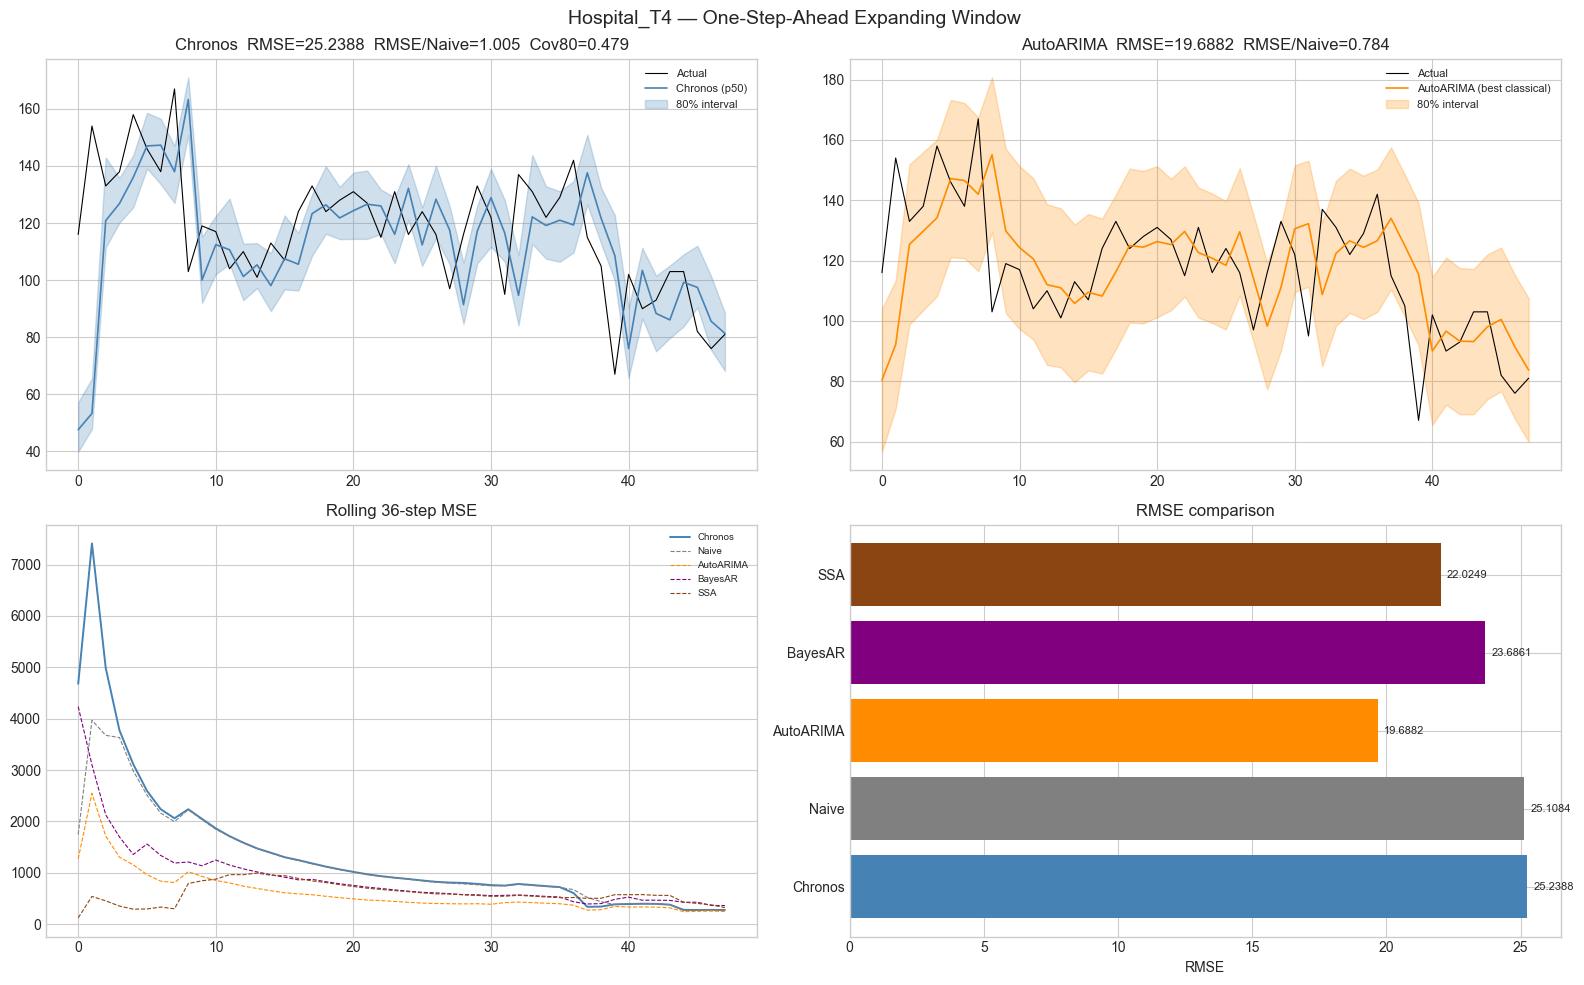

Saved results/similar_domain/plots/Hospital_T4_benchmark.png


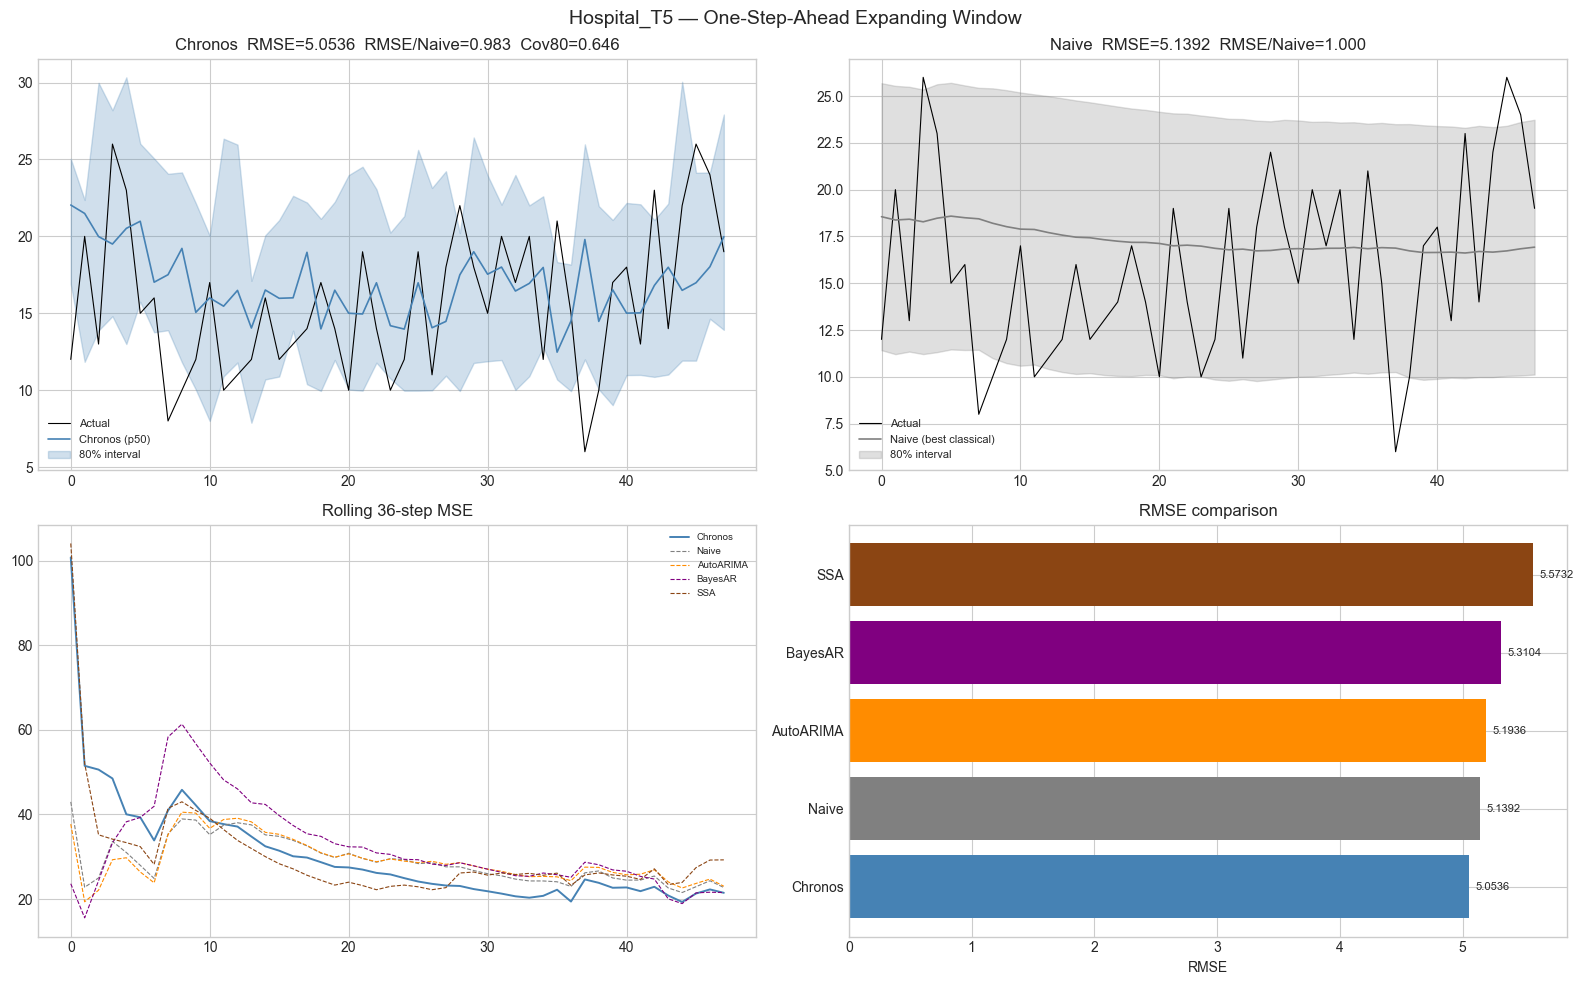

Saved results/similar_domain/plots/Hospital_T5_benchmark.png


In [31]:
for ds_name, res in dataset_results.items():
    actuals = res['actuals']
    preds   = res['preds']
    lowers  = res['lowers']
    uppers  = res['uppers']
    idx     = np.arange(len(actuals))

    ds_metrics = {r['model']: r for r in all_metrics_rows if r['dataset'] == ds_name}
    classical_names = [m for m in MODEL_NAMES if m != 'Chronos']
    best_classical  = min(classical_names, key=lambda m: ds_metrics[m].get('rmse', float('inf')))

    fig, axes = plt.subplots(2, 2, figsize=(16, 10))
    fig.suptitle(f'{ds_name} — One-Step-Ahead Expanding Window', fontsize=14)

    ax = axes[0, 0]
    ax.plot(idx, actuals, 'k', lw=0.8, label='Actual')
    if RUN_CHRONOS:
        ax.plot(idx, preds['Chronos'], color=COLORS['Chronos'], lw=1.2, label='Chronos (p50)')
        lo_c = np.array(lowers['Chronos'], dtype=float)
        hi_c = np.array(uppers['Chronos'], dtype=float)
        ax.fill_between(idx, lo_c, hi_c, color=COLORS['Chronos'], alpha=0.25, label='80% interval')
        cm = ds_metrics['Chronos']
        ax.set_title(f"Chronos  RMSE={cm['rmse']:.4f}  RMSE/Naive={cm['rmse_over_naive']:.3f}  Cov80={cm['coverage_80']:.3f}")
    else:
        ax.set_title('Chronos (disabled)')
    ax.legend(fontsize=8); ax.grid(True)

    ax = axes[0, 1]
    ax.plot(idx, actuals, 'k', lw=0.8, label='Actual')
    ax.plot(idx, preds[best_classical], color=COLORS[best_classical], lw=1.2,
            label=f'{best_classical} (best classical)')
    lo_b = np.array(lowers[best_classical], dtype=float)
    hi_b = np.array(uppers[best_classical], dtype=float)
    if not np.all(np.isnan(lo_b)):
        ax.fill_between(idx, lo_b, hi_b, color=COLORS[best_classical], alpha=0.25, label='80% interval')
    bm = ds_metrics[best_classical]
    ax.set_title(f"{best_classical}  RMSE={bm['rmse']:.4f}  RMSE/Naive={bm['rmse_over_naive']:.3f}")
    ax.legend(fontsize=8); ax.grid(True)

    ax = axes[1, 0]
    for model in MODEL_NAMES:
        se = (np.array(preds[model], dtype=float) - actuals) ** 2
        ax.plot(rolling_mean(se, ROLLING_WINDOW), color=COLORS[model],
                lw=1.4 if model == 'Chronos' else 0.8,
                ls='-'  if model == 'Chronos' else '--', label=model)
    ax.set_title(f'Rolling {ROLLING_WINDOW}-step MSE')
    ax.legend(fontsize=7); ax.grid(True)

    ax = axes[1, 1]
    rmse_vals = [ds_metrics[m]['rmse'] for m in MODEL_NAMES]
    bars = ax.barh(MODEL_NAMES, rmse_vals, color=[COLORS[m] for m in MODEL_NAMES])
    ax.set_title('RMSE comparison'); ax.set_xlabel('RMSE'); ax.grid(True, axis='x')
    for bar, val in zip(bars, rmse_vals):
        ax.text(val * 1.01, bar.get_y() + bar.get_height() / 2, f'{val:.4f}', va='center', fontsize=8)

    plt.tight_layout()
    save_path = RESULTS_DIR / 'plots' / f'{ds_name}_benchmark.png'
    plt.savefig(save_path, dpi=120, bbox_inches='tight')
    plt.show()
    print(f"Saved {save_path}")

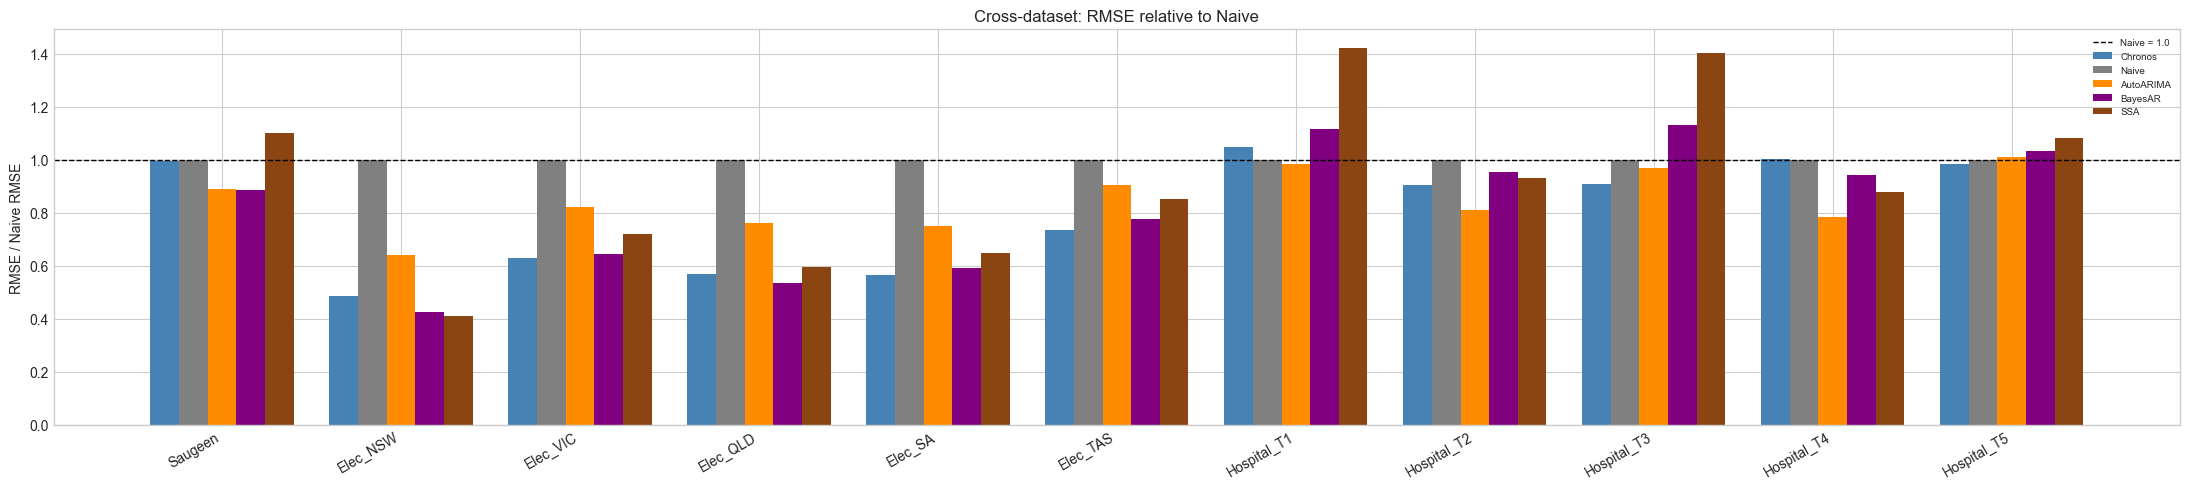

In [32]:
if len(dataset_results) > 1:
    summary  = metrics_df.pivot(index='model', columns='dataset', values='rmse_over_naive')
    ds_names = list(dataset_results.keys())
    x, width = np.arange(len(ds_names)), 0.8 / len(MODEL_NAMES)
    fig, ax = plt.subplots(figsize=(max(8, len(ds_names) * 2), 5))
    for i, model in enumerate(MODEL_NAMES):
        vals = [summary.loc[model, d] if d in summary.columns else float('nan') for d in ds_names]
        ax.bar(x + i * width, vals, width, label=model, color=COLORS[model])
    ax.axhline(1.0, color='black', ls='--', lw=1, label='Naive = 1.0')
    ax.set_xticks(x + width * (len(MODEL_NAMES) - 1) / 2)
    ax.set_xticklabels(ds_names, rotation=30, ha='right')
    ax.set_ylabel('RMSE / Naive RMSE')
    ax.set_title('Cross-dataset: RMSE relative to Naive')
    ax.legend(fontsize=7); ax.grid(True, axis='y')
    plt.tight_layout()
    plt.savefig(RESULTS_DIR / 'plots' / 'cross_dataset_summary.png', dpi=120, bbox_inches='tight')
    plt.show()
else:
    ds_name = list(dataset_results.keys())[0]
    display(metrics_df[metrics_df['dataset'] == ds_name]
            [['model', 'rmse', 'rmse_over_naive', 'coverage_80', 'avg_interval_width']]
            .sort_values('rmse').reset_index(drop=True))

In [33]:
# ── Pooled summary across all active datasets (scale-free metrics only) ──────
scale_free_cols = ['rmse_over_naive', 'mae_over_naive', 'coverage_80', 'interval_width_over_naive']

pooled = (
    pd.DataFrame(all_metrics_rows)
    .groupby('model')[scale_free_cols]
    .mean()
    .round(2)
    .reindex(MODEL_NAMES)
)
pooled.index.name = 'model'
pooled.columns = ['RMSE / Naive', 'MAE / Naive', 'Coverage 80%', 'Width / Naive']

styled = (
    pooled.style
    .background_gradient(subset=['RMSE / Naive'],  cmap='RdYlGn_r', axis=0)
    .background_gradient(subset=['MAE / Naive'],   cmap='RdYlGn_r', axis=0)
    .background_gradient(subset=['Coverage 80%'],  cmap='RdYlGn',   axis=0)
    .background_gradient(subset=['Width / Naive'], cmap='RdYlGn_r', axis=0)
    .format('{:.2f}')
    .set_caption('Pooled metrics — mean across active datasets (scale-free, relative to Naive)')
)

print('Reference: Naive = 1.00 for ratio columns | ideal Coverage 80% = 0.80')
display(styled)

Reference: Naive = 1.00 for ratio columns | ideal Coverage 80% = 0.80


,RMSE / Naive,MAE / Naive,Coverage 80%,Width / Naive
model,,,,
Chronos,0.80,0.76,0.69,0.53
Naive,1.00,1.00,0.79,1.00
AutoARIMA,0.85,0.86,0.80,0.83
BayesAR,0.82,0.80,0.85,0.86
SSA,0.91,0.94,0.76,0.91
